coverage plot

In [113]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from sbi import utils as utils
from sbi import analysis as analysis
from sbi.inference.base import infer

In [114]:
num_dim = 1
prior_uniform = utils.BoxUniform(low = 0 * torch.ones(num_dim), high = 10 * torch.ones(num_dim))

In [115]:
def simple_relation(phi1s, M_sat, scatter=0.1):

    phi2s = phi1s/M_sat

    phi1s = np.array(phi1s)
    phi2s = np.array(phi2s)
    
    positions = np.concatenate([phi1s,phi2s])
    positions = torch.from_numpy(positions)
    
    return positions + torch.randn_like(positions) * scatter

# print(simple_relation(np.arange(10), 0.1, 0.1))

In [116]:
def simulator(params, n_obs=100, scatter=0.1):
    params = torch.as_tensor(params)
    M_sat = params[0]

    # phi1 values evenly spaced
    phi1s = np.arange(n_obs)
    phi1s = torch.tensor(phi1s)

    return simple_relation(phi1s, M_sat, scatter)

In [143]:
posterior = infer(simulator, prior_uniform, "SNPE", num_simulations=10)

Running 10 simulations.: 100%|██████████| 10/10 [00:00<00:00, 4336.54it/s]


 Neural network successfully converged after 51 epochs.

In [130]:
def hpd(trace, mass_frac):
    ''' 
    Returns highest probability density region given by a set of samples.

    Parameters
    ----------
    trace: array
        1D array of MCMC samples for a single variable
    mass_frac: float with 0 < mass_frac <= 1
        The fraction of the probability to be included in the HPD. For example, 'massfrac'=0.95 gives a 95% HPD.

    Returns
    -------
    output: array, shape(2,)
        The bounds of the HPD
    '''

    # Get sorted list
    d = np.sort(np.copy(trace))

    # Number of total samples taken
    n = len(trace)

    # Get number of samples that should be included in HPD
    n_samples = np.floor(mass_frac * n).astype(int)

    # Get width (in units of data) of all intervals with n_samples samples
    int_width = d[n_samples:] - d[:n-n_samples]

    # Pick out minimal interval
    min_int = np.argmin(int_width)

    # Return interval
    return np.array([d[min_int], d[min_int+n_samples]])

In [138]:
# simple version

def draw_coverage_plot_1d(simulator, posterior, true_values):
    fractions = np.array([])
    x = np.arange(0, 1, 0.1)

    for j in x:
        contain_true = 0
        for k in true_values:
            samples = posterior.sample((1000,), x = simulator(torch.as_tensor([k])))[:,0]
            samples = np.array(samples)
            lower_bound, upper_bound = hpd(samples, j)
            if lower_bound <= k <= upper_bound:
                contain_true += 1
    
        fractions = np.append(fractions, [contain_true/len(true_values)])

    

    plt.plot(x, fractions)
    plt.ylim(0,1)
    plt.title("coverage for M_sat")
    plt.xlabel("confidence interval")
    plt.ylabel("covereage percentage")
    plt.show()

Drawing 1000 posterior samples: 1110it [00:00, 31870.74it/s]            
Drawing 1000 posterior samples: 1180it [00:00, 44073.90it/s]            
Drawing 1000 posterior samples: 1212it [00:00, 46673.12it/s]            
Drawing 1000 posterior samples: 1039it [00:00, 63149.47it/s]            
Drawing 1000 posterior samples: 1088it [00:00, 57856.87it/s]            
Drawing 1000 posterior samples: 1135it [00:00, 43126.26it/s]            
Drawing 1000 posterior samples: 1222it [00:00, 43288.82it/s]            
Drawing 1000 posterior samples: 1222it [00:00, 41383.25it/s]            
Drawing 1000 posterior samples: 1306it [00:00, 22868.12it/s]            
Drawing 1000 posterior samples: 1264it [00:00, 29540.15it/s]            
Drawing 1000 posterior samples: 1268it [00:00, 27773.51it/s]            
Drawing 1000 posterior samples: 1165it [00:00, 37118.30it/s]            
Drawing 1000 posterior samples: 1159it [00:00, 40049.75it/s]            
Drawing 1000 posterior samples: 1169it [00:00, 3900

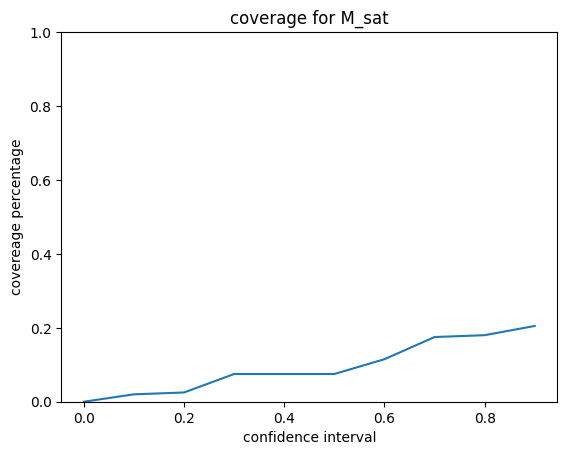

In [144]:
true_values = np.arange(0.05,10.05,0.05)
draw_coverage_plot_1d(simulator, posterior, true_values)


In [146]:
# to be updated
# input simulator (to calculate observation), trained posterior model, true_values to be tested

def draw_coverage_plot(simulator, posterior, true_values):
    fractions = np.array([])
    x = np.arange(0, 1, 0.1)
    num_variables = len(true_values[0])


    for i in range(num_variables):
        for j in x:
            contain_true = 0
            for k in true_values:
                samples = posterior.sample((1000,), x = simulator(torch.as_tensor(k)))
                lower_bound, upper_bound = hpd(np.array(samples[:,i]), j)
                if lower_bound <= k[i] <= upper_bound:
                    contain_true += 1
        
        fractions = np.append(fractions, [contain_true/len(true_values[0])])
    
    plt.plot(x, fractions)
    plt.title("f'coverage for {i}'")
    plt.show()

TypeError: object of type 'numpy.float64' has no len()